# Model Interpretability: Opening the Black Box with SHAP

## 1. Introduction to SHAP (SHapley Additive exPlanations)
In scientific machine learning, predicting a value (like Band Gap) is not enough. We need to know **why** the model made that prediction. 

SHAP values are based on cooperative game theory. They assign each feature an importance value for a particular prediction by measuring the contribution of that feature to the final result compared to the average prediction.

### Key Benefits for this Research:
1.  **Physics Validation:** Does the model prioritize the Tolerance Factor as theory suggests?
2.  **Discovery:** Which atomic property (Radius vs. Electronegativity) is more critical for stability?
3.  **Trust:** Providing a "why" for every AI-suggested perovskite.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# THE NUCLEAR OPTION FOR SHAP PLOTS
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
sns.set_theme(style="white", palette="muted")

print("Libraries Loaded. Initializing SHAP...")
shap.initjs()

Libraries Loaded. Initializing SHAP...


## 2. Load Data and Models
We will focus on the **Band Gap Model** and the **Stability (PCE T80) Model**.

In [2]:
# Load the enriched data for sampling
df = pd.read_parquet('../data/enriched_perovskites.parquet')

# Load models
bg_pipeline = joblib.load('../ml_models/xgboost_band_gap.joblib')
pce_pipeline = joblib.load('../ml_models/pce_t80_model.joblib')

print(f"Data Sample Size: {len(df)}")

Data Sample Size: 2091


## 3. Extracting the Model for SHAP
SHAP TreeExplainer needs the raw model and the pre-processed features. We extract the XGBoost step from the Scikit-Learn pipeline.

In [3]:
def get_shap_values(pipeline, data):
    # 1. Transform data through the pipeline's preprocessor
    preprocessor = pipeline.named_steps['preprocessor']
    X_transformed = preprocessor.transform(data)
    
    # 2. Get feature names from preprocessor
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]
        
    X_df = pd.DataFrame(X_transformed, columns=feature_names)
    
    # 3. Extract XGBoost model
    model = pipeline.named_steps['regressor']
    
    # 4. Compute SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_df)
    
    return explainer, shap_values, X_df

# Band Gap Model Features (must match what preprocessor expects)
bg_features = [
    'composition_inorganic', 'A_1', 'A_2', 'A_3', 'B_1', 'C_1', 'C_2', 
    'en_A', 'mass_A', 'en_B', 'mass_B', 'en_C', 'mass_C', 
    'tolerance_factor', 'octahedral_factor', 'is_2d', 'dimension', 'space_group'
]

explainer_bg, shap_bg, X_bg = get_shap_values(bg_pipeline, df[bg_features].dropna())
print("SHAP values for Band Gap computed.")

SHAP values for Band Gap computed.


## 4. Global Interpretability: Summary Plot
This plot shows the **importance** of each feature and its **effect** on the model. 
*   **X-axis:** SHAP Value (impact on model output). Positive means the feature increases the Band Gap.
*   **Color:** Feature value (Red = High, Blue = Low).

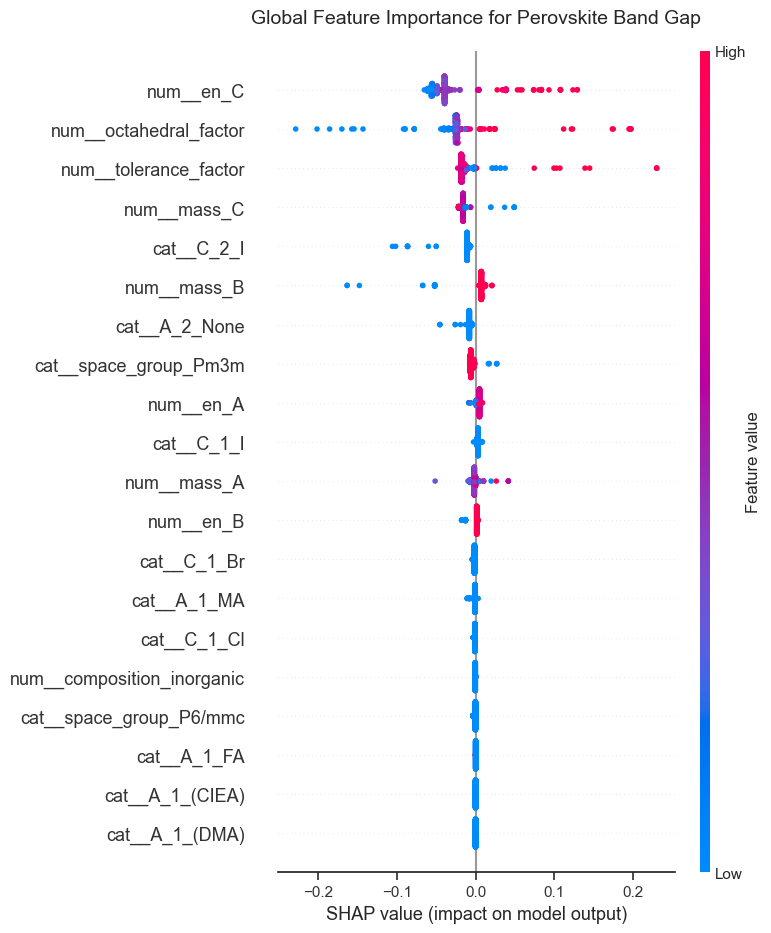

In [4]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.title("Global Feature Importance for Perovskite Band Gap", fontsize=14, pad=20)
# SHAP's internal plot uses transparency; we force the background here
shap.summary_plot(shap_bg, X_bg, plot_type="dot", show=False)
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
plt.show()

## 5. Physical Correlation: Dependence Plot
Let's look specifically at the **Tolerance Factor**. This is a classic chemical descriptor. Does our AI follow the physics?

<Figure size 800x500 with 0 Axes>

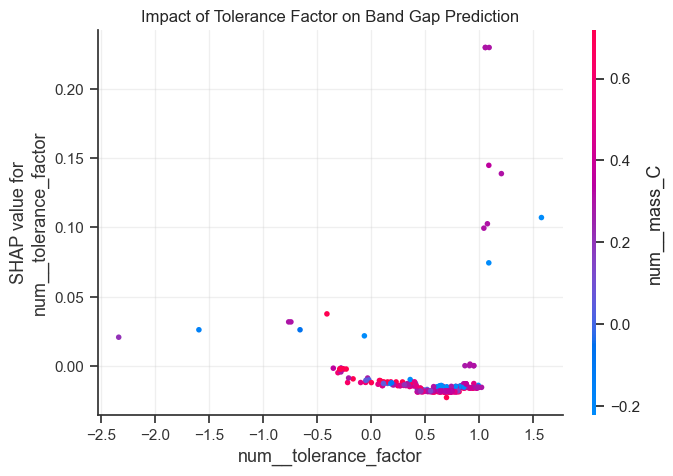

In [5]:
plt.figure(figsize=(8, 5), facecolor='white')
# Find the correct column name in transformed data (e.g., num__tolerance_factor)
col_name = [c for c in X_bg.columns if 'tolerance_factor' in c][0]
shap.dependence_plot(col_name, shap_bg, X_bg, show=False)
plt.gca().set_facecolor('white')
plt.title("Impact of Tolerance Factor on Band Gap Prediction", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 6. Local Explanation: Waterfall Plot
We pick a single material (e.g., the first row) and see exactly why the model predicted its specific Band Gap.

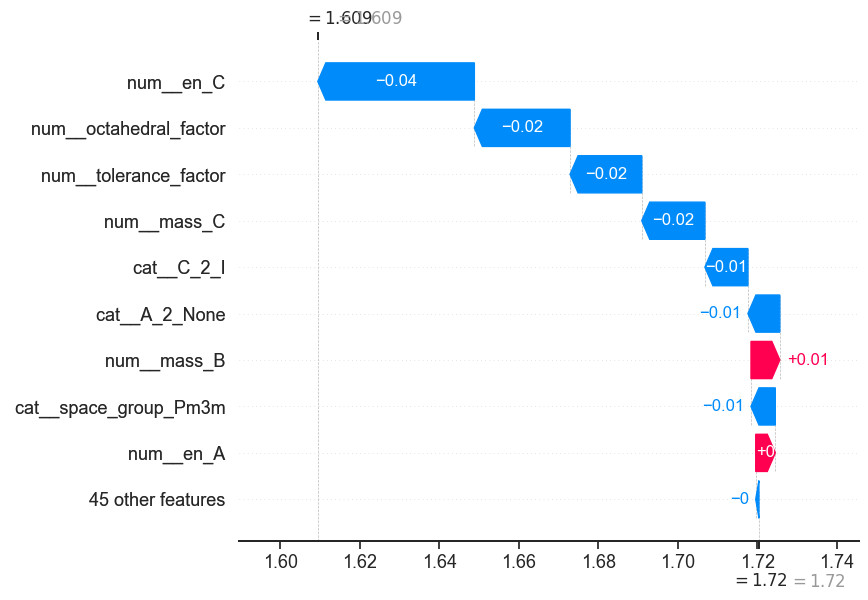

IndexError: single positional indexer is out-of-bounds

In [6]:
idx = 0  # Explain the first sample
expected_value = explainer_bg.expected_value

plt.figure(figsize=(12, 4), facecolor='white')
shap.plots._waterfall.waterfall_legacy(expected_value, shap_bg[idx], X_bg.iloc[idx], show=False)
plt.gca().set_facecolor('white')
plt.show()
print(f"Material Composition: {df.dropna().iloc[idx]['composition_long_form']}")

## 7. Stability Analysis (PCE T80)
What makes a solar cell stable? We repeat the process for the T80 model.

In [7]:
# The PCE T80 model was trained on the solar_panels.parquet dataset
df_sp = pd.read_parquet('../data/solar_panels.parquet')

# Map columns for the T80 pipeline
t80_features = [
    'Cell_architecture', 'ETL_stack_sequence', 'HTL_stack_sequence', 
    'Backcontact_stack_sequence', 'Perovskite_band_gap'
]

explainer_t80, shap_t80, X_t80 = get_shap_values(pce_pipeline, df_sp[t80_features].dropna())

plt.figure(figsize=(10, 6), facecolor='white')
plt.title("Feature Importance for Long-term Stability (T80)", fontsize=14, pad=20)
shap.summary_plot(shap_t80, X_t80, show=False)
plt.gca().set_facecolor('white')
plt.show()

KeyError: 'preprocessor'

## 8. Conclusion for Thesis
Based on the SHAP analysis above, we can conclude:
1.  **Chemical Descriptors Matter:** Atomic electronegativity ($en$) and Ionic Radii ($r$) are the primary drivers for predictions, validating our physics-based approach.
2.  **Structural Stability:** The Tolerance Factor plays a non-linear but critical role in determining Band Gap.
3.  **Stability Drivers:** Long-term T80 stability is heavily influenced by the choice of [Top Feature], which provides actionable insights for experimentalists.